In [1]:
import os
os.chdir('/workspace/96ab667f-4489-43d1-b376-4f365308b4b1')
os.listdir('.')


['.config',
 'M_emp_50.npy',
 'cos_theory_emp200.npy',
 ' v6 — Binding Context Document.pdf',
 'pc1_var_200.npy',
 'eig_emp_200.npy',
 '.kernel_llm_logs_1.txt',
 'eigvec_emp_50.npy',
 '.prompts',
 'pc1_var_50.npy',
 'M_emp_200.npy',
 'cos_theory_emp50.npy',
 'eig_theory.npy',
 'eigvec_emp_200.npy',
 'M_theory_tuned.npy',
 'pc1_var_theory.npy',
 'eig_emp_50.npy',
 'eigvec_theory.npy',
 'memory']

In [2]:
import numpy as np
# Look for the canonical input files mentioned in the description.
# We need Sk_complex_all_2200peaks.npz (r38) or component files Sk_re.npy, Sk_im.npy, t_peaks.npy, absD_peaks.npy.
import subprocess
print(subprocess.run(['find', '/workspace', '-maxdepth', '4', '-name', 'Sk*'], capture_output=True, text=True).stdout)
print(subprocess.run(['find', '/workspace', '-maxdepth', '4', '-name', '*peaks*'], capture_output=True, text=True).stdout)
print(subprocess.run(['find', '/workspace', '-maxdepth', '4', '-name', 'Mjk*'], capture_output=True, text=True).stdout)


In [3]:
print(subprocess.run(['find', '/workspace', '-maxdepth', '6', '-name', 'Mjk*'], capture_output=True, text=True).stdout)
print(subprocess.run(['find', '/workspace', '-maxdepth', '6', '-name', 'Sk*'], capture_output=True, text=True).stdout)
print(subprocess.run(['find', '/workspace', '-maxdepth', '6', '-name', 't_peaks*'], capture_output=True, text=True).stdout)
print(subprocess.run(['find', '/workspace', '-maxdepth', '6', '-name', 'peaks_features*'], capture_output=True, text=True).stdout)


In [4]:
M_emp_200 = np.load('M_emp_200.npy')
eig_emp_200 = np.load('eig_emp_200.npy')
eigvec_emp_200 = np.load('eigvec_emp_200.npy')
pc1_var_200 = np.load('pc1_var_200.npy')
M_theory_tuned = np.load('M_theory_tuned.npy')
eig_theory = np.load('eig_theory.npy')
pc1_var_theory = np.load('pc1_var_theory.npy')
cos_theory_emp200 = np.load('cos_theory_emp200.npy')

print("M_emp_200 shape:", M_emp_200.shape)
print("eigenvalues empirical:", eig_emp_200)
print("PC1 var fraction empirical (200):", pc1_var_200)
print()
print("M_theory_tuned shape:", M_theory_tuned.shape)
print("eigenvalues theory tuned:", eig_theory)
print("PC1 var theory tuned:", pc1_var_theory)
print("Cos sim theory-emp 200:", cos_theory_emp200)
print()
print("Empirical PC1 eigenvector (top 200):")
print(eigvec_emp_200)


M_emp_200 shape: (8, 8)
eigenvalues empirical: [3.73221917e+01 3.06853029e+00 1.47383127e+00 7.29552178e-01
 4.45520298e-01 4.05244214e-02 1.41354927e-03 8.16830094e-06]
PC1 var fraction empirical (200): 0.8663145299644283

M_theory_tuned shape: (8, 8)
eigenvalues theory tuned: [4.69559094e+00 2.26665741e+00 1.29915488e+00 6.57206214e-01
 3.39663604e-01 9.14688843e-02 2.90354168e-03 4.29526788e-06]
PC1 var theory tuned: 0.5020599565937205
Cos sim theory-emp 200: 0.936302167473425

Empirical PC1 eigenvector (top 200):
[[-9.98177824e-02 -4.55588814e-02 -2.19694737e-01 6.81718362e-01
 -6.89131074e-01 6.94796051e-03 -2.26543364e-03 2.31580943e-04]
 [-3.56652567e-01 -5.61959243e-01 -7.07480724e-01 -2.09189065e-01
 1.07061337e-01 -3.53483820e-02 -2.78485751e-04 -2.50547839e-05]
 [-5.51732488e-01 -5.08981662e-01 6.52340528e-01 1.03485980e-01
 8.11777402e-03 1.43283790e-02 -3.78993792e-04 -2.68121346e-04]
 [-6.43094803e-01 5.65187222e-01 -1.55286629e-01 2.86061661e-01
 3.89224998e-01 9.7286148

In [5]:
# The first column of eigvec_emp_200 is the empirical PC1 eigenvector.
# Confirm by sorting eigenvalues - they appear already sorted in descending order.
emp_pc1 = eigvec_emp_200[:, 0]
print("Empirical PC1 vector (8-dim, ω-strata):", emp_pc1)
print("Norm:", np.linalg.norm(emp_pc1))
# So we have 8 ω-strata. Let's understand: ω(n) for n in 1..N, distinct prime factor counts
# typically range from 0 (n=1) to ~7-8 (for N=10^6). So 8 strata k=0..7.
print()
print("Empirical M_emp_200 diagonal:", np.diag(M_emp_200))


Empirical PC1 vector (8-dim, ω-strata): [-9.98177824e-02 -3.56652567e-01 -5.51732488e-01 -6.43094803e-01
 -3.70872259e-01 -8.52315535e-02 -6.71134807e-03 -3.60746534e-05]
Norm: 1.0000000000000002

Empirical M_emp_200 diagonal: [1.00000000e+00 6.49123616e+00 1.27911788e+01 1.65786925e+01
 5.88081922e+00 3.36158396e-01 3.47813697e-03 8.61698608e-06]


In [6]:
# Plan:
# 1. Generate fine-grid R(t) = sum_{n<=100} mu(n)^2 / sqrt(n) * n^{-it}
# 2. Find 200 highest peaks of |R(t)| in t in [0, 1e5]
# 3. At those peak times, compute S_k(t) = sum_{n<=N: omega(n)=k} a_n * n^{-it}
# For Riemann zeta, a_n = 1.
# But the empirical M is normalized; need to look at normalization. Let's pick N modest first.
# 
# Computational considerations:
# - Fine grid: need ~5 samples per oscillation. Highest frequency in R(t): n=100, log(100)~4.6
# So Δt ~ 2π/(5*4.6) ≈ 0.27. For t∈[0,1e5], that's 3.7e5 samples. Manageable.
# But to find sharp peaks accurately, we want even finer. Let's use Δt = 0.05 → 2e6 samples.
# That's 2e6 * 100 ops = 2e8 - feasible with vectorization.
# - For S_k: at 200 peaks, with N=1e6, we need sum at each peak — 200 * 1e6 = 2e8 multiplications.
# Doable but heavy. We need omega(n) sieve up to 1e6 and group n by omega.

# Step 1: Build R(t) on a grid.
import numpy as np

# Mobius squared: μ²(n) = 1 iff n is squarefree.
def squarefree_mask(N):
 sieve = np.ones(N+1, dtype=bool)
 sieve[0] = False
 for p in range(2, int(N**0.5)+1):
 if sieve[p] or True:
 # Check primality manually
 pass
 # Use simpler: check squarefree by sieve of p^2
 sf = np.ones(N+1, dtype=bool)
 sf[0] = False
 for p in range(2, int(np.sqrt(N))+1):
 is_p = True
 for q in range(2, int(np.sqrt(p))+1):
 if p % q == 0:
 is_p = False; break
 if is_p:
 sf[p*p::p*p] = False
 return sf

N_R = 100
sf = squarefree_mask(N_R)
n_arr = np.arange(1, N_R+1)
mask = sf[1:N_R+1]
n_used = n_arr[mask]
weights = 1.0 / np.sqrt(n_used) # μ²(n)/√n
log_n = np.log(n_used)
print("Squarefree n ≤ 100:", len(n_used), "values")
print("First few:", n_used[:10])


Squarefree n ≤ 100: 61 values
First few: [ 1 2 3 5 6 7 10 11 13 14]


In [7]:
# Step 2: Compute |R(t)| on a fine grid t in [0, 1e5] with dt=0.05
# Then find 200 highest local maxima.
# To save memory, do it in chunks.

import numpy as np
from scipy.signal import find_peaks

T_max = 1e5
dt = 0.05
n_t = int(T_max/dt) + 1
print(f"Total samples: {n_t}")

# Process in chunks
chunk_size = 200000
t_peaks_all = []
val_peaks_all = []

# We'll find all local maxima in each chunk (with overlap handling), then keep top 200 globally.
# For chunked find_peaks, ensure we don't miss peaks at chunk boundaries.

prev_tail_t = None
prev_tail_v = None
overlap = 100 # samples

start = 0
while start < n_t:
 end = min(start + chunk_size, n_t)
 # include overlap at start (except first)
 s = max(0, start - overlap)
 e = min(n_t, end + overlap)
 t_chunk = np.arange(s, e) * dt
 # Compute R(t) = sum weights * exp(-i*t*log(n))
 # |R(t)|² then sqrt
 # Outer product: (e-s, len(weights))
 phases = -np.outer(t_chunk, log_n)
 R = np.cos(phases) @ weights + 1j * (np.sin(phases) @ weights)
 absR = np.abs(R)
 peaks, _ = find_peaks(absR)
 # Keep only peaks within [start, end) absolute index
 abs_idx = peaks + s
 in_range = (abs_idx >= start) & (abs_idx < end)
 peaks = peaks[in_range]
 abs_idx = abs_idx[in_range]
 if len(peaks) > 0:
 t_peaks_all.append(t_chunk[peaks])
 val_peaks_all.append(absR[peaks])
 start = end

t_peaks_all = np.concatenate(t_peaks_all)
val_peaks_all = np.concatenate(val_peaks_all)
print(f"Total local maxima found: {len(t_peaks_all)}")


Total samples: 2000001


Total local maxima found: 58727


In [8]:
# Now refine the top ~400 peaks via local quadratic / Newton refinement, then keep top 200.
# Take top 400 first by raw amplitude.
order = np.argsort(val_peaks_all)[::-1]
top_idx = order[:400]
t_candidates = t_peaks_all[top_idx]
v_candidates = val_peaks_all[top_idx]

# Refine each using golden-section / scalar maximization in a small window around the candidate.
from scipy.optimize import minimize_scalar

def absR(t):
 # vectorize-friendly for scalar
 phases = -t * log_n
 return abs(np.dot(np.exp(1j*phases), weights))

def neg_absR(t):
 return -absR(t)

t_refined = np.empty_like(t_candidates)
v_refined = np.empty_like(v_candidates)
for i, t0 in enumerate(t_candidates):
 res = minimize_scalar(neg_absR, bracket=(t0-dt, t0, t0+dt), method='brent', options={'xtol':1e-8})
 t_refined[i] = res.x
 v_refined[i] = -res.fun

# Now keep top 200 by refined amplitude.
order2 = np.argsort(v_refined)[::-1]
top200 = order2[:200]
t_peaks = np.sort(t_refined[top200])
v_peaks = v_refined[top200][np.argsort(t_refined[top200])]
print("Top 200 peak amplitudes range:", v_peaks.min(), v_peaks.max())
print("Top 200 t-range:", t_peaks.min(), t_peaks.max())
print("First 5 peaks:", list(zip(t_peaks[:5], v_peaks[:5])))


Top 200 peak amplitudes range: 6.812140999504865 8.449313570208988
Top 200 t-range: 4071.576725411324 99937.94180433977
First 5 peaks: [(np.float64(4071.576725411324), np.float64(6.8199959441409765)), (np.float64(4404.2594344190475), np.float64(6.987183998312237)), (np.float64(5793.262045406554), np.float64(6.917127465462666)), (np.float64(7378.275044850196), np.float64(6.9731933126199275)), (np.float64(8647.01250412089), np.float64(7.319673202828967))]


In [9]:
# Step 3: At these t_peaks, compute ω-stratified sums S_k(t) = Σ_{n≤N, ω(n)=k} a_n n^{-it}
# For Riemann zeta, a_n = 1.
# We need ω(n) sieve up to N=1e6, group n by ω(n), and compute sum_{n in stratum} n^{-it}
# Strata k=0..7 (8 strata).

N = 10**6

# Sieve ω(n) = number of distinct prime factors
omega = np.zeros(N+1, dtype=np.int8)
for p in range(2, N+1):
 if omega[p] == 0 and p > 1:
 # p is prime if omega[p]==0... but we set ω(1)=0, ω(prime)=1
 # The check needs to be sieve-style.
 pass

# Standard linear sieve approach
omega = np.zeros(N+1, dtype=np.int8)
is_composite = np.zeros(N+1, dtype=bool)
for i in range(2, N+1):
 if not is_composite[i]:
 # i is prime
 omega[i::i] += 1
 is_composite[i*i::i] = True
# This is the simple "for each prime p, increment omega for multiples of p"
# but the is_composite marking only marks p*p, p*p+p,... which may miss compositeness checks.
# Actually for omega, we don't need primality of i; we need to add 1 if i is prime.
# Let's do it correctly:
omega = np.zeros(N+1, dtype=np.int8)
sieve = np.ones(N+1, dtype=bool)
sieve[:2] = False
for i in range(2, int(np.sqrt(N))+1):
 if sieve[i]:
 sieve[i*i::i] = False
# sieve marks primes correctly
primes = np.where(sieve)[0]
print(f"Num primes ≤ {N}: {len(primes)}")
for p in primes:
 omega[p::p] += 1
print("omega range:", omega.min(), omega.max())
print("ω distribution:", np.bincount(omega))


Num primes ≤ 1000000: 78498
omega range: 0 7
ω distribution: [ 2 78734 288726 379720 208034 42492 2285 8]


In [10]:
# 8 strata with k=0..7. ω=0 has only n=1 (and a duplicate from sieve indexing - let me check)
print("indices with ω=0:", np.where(omega==0)[0])
# n=1 has ω=1=0. n=0 is unused. Good - so 2 entries at index 0 and 1.
# Actually omega[0]=0 because n=0 was untouched. omega[1]=0 because 1 is in nothing.
# We will use n from 1 to N only.


indices with ω=0: [0 1]


In [11]:
# Group n by omega.
# Strata: k=0 (n=1), k=1, ..., k=7 (8 strata). 
n_arr_full = np.arange(1, N+1)
omega_full = omega[1:N+1]
strata = {k: n_arr_full[omega_full == k].astype(np.float64) for k in range(8)}
for k in range(8):
 print(f"ω={k}: {len(strata[k])} elements")

# Precompute log(n) for each stratum once
log_strata = {k: np.log(strata[k]) for k in range(8)}


ω=0: 1 elements
ω=1: 78734 elements
ω=2: 288726 elements
ω=3: 379720 elements
ω=4: 208034 elements
ω=5: 42492 elements
ω=6: 2285 elements
ω=7: 8 elements


In [12]:
# Now compute S_k(t) for each of 200 peaks and each stratum k.
# Strategy: for each stratum, we have an array of log_n. For 200 t values, 
# we need sum_{n in stratum} exp(-i*t*log(n))
# Total work: 200 * (1 + 78734 + 288726 + 379720 + 208034 + 42492 + 2285 + 8) ≈ 200 * 1e6 = 2e8 ops
# Let's do this with the standard approach but use double precision carefully (Kahan if needed).
# 
# Actually we should match the dataset's pipeline which uses Kahan compensated summation.
# But for ~1e6 sum at moderate t (up to 1e5), float64 should be reasonable; cumulative error ~ 1e6 * 1e-16 = 1e-10.
# That's much smaller than the spectral structure we're after.
#
# Use chunking to limit memory: for each stratum, process t_peaks in batches.

n_peaks = len(t_peaks)
n_strata = 8
S = np.zeros((n_peaks, n_strata), dtype=np.complex128)

for k in range(n_strata):
 if len(strata[k]) == 0: continue
 n_vals = strata[k]
 log_n_vals = log_strata[k]
 if len(n_vals) <= 1:
 # Trivial sum: just use directly
 for i, t in enumerate(t_peaks):
 S[i, k] = np.sum(np.exp(-1j*t*log_n_vals))
 continue
 # Chunk over n to limit memory
 n_chunk = 100000
 for i_start in range(0, n_peaks, 50):
 i_end = min(i_start+50, n_peaks)
 t_batch = t_peaks[i_start:i_end] # shape (b,)
 # Accumulate over n-chunks
 S_batch = np.zeros((i_end-i_start,), dtype=np.complex128)
 for ns in range(0, len(log_n_vals), n_chunk):
 ne = min(ns+n_chunk, len(log_n_vals))
 log_n_chunk = log_n_vals[ns:ne] # shape (m,)
 phases = -np.outer(t_batch, log_n_chunk) # (b, m)
 S_batch += np.cos(phases).sum(axis=1) + 1j*np.sin(phases).sum(axis=1)
 S[i_start:i_end, k] = S_batch
 print(f"Stratum k={k}: done. |S_k| range: {np.abs(S[:,k]).min():.3f} to {np.abs(S[:,k]).max():.3f}")


Stratum k=1: done. |S_k| range: 6.066 to 347.985


Stratum k=2: done. |S_k| range: 42.399 to 853.320


Stratum k=3: done. |S_k| range: 36.831 to 1296.028


Stratum k=4: done. |S_k| range: 53.479 to 1624.845


Stratum k=5: done. |S_k| range: 11.949 to 1230.046
Stratum k=6: done. |S_k| range: 5.903 to 380.728
Stratum k=7: done. |S_k| range: 0.498 to 7.179


In [13]:
# Stratum k=0 (just n=1): |S_0| = 1 always.
S[:, 0] = 1.0 # since exp(-i*t*log(1)) = 1
print("S shape:", S.shape)

# Step 4: Compute M_jk(extreme) = E[Re(S_j conj(S_k))] over peaks.
# That's the empirical covariance in real terms.
# Need the same normalization as M_emp_200. Let's check how M_emp_200 was normalized:
# diag of M_emp_200 = [1.0, 6.49, 12.79, 16.58, 5.88, 0.336, 0.0035, 8.6e-6]
# So entry (0,0) = 1, meaning E[|S_0|²] = 1, consistent with raw S_0=1.
# Then the entries represent M_jk = mean_t Re(S_j(t) S_k(t)*).
# Let's compute it both raw and possibly with some normalization.

M_extreme = np.zeros((8, 8))
for j in range(8):
 for k in range(8):
 M_extreme[j,k] = np.mean(np.real(S[:,j] * np.conj(S[:,k])))

print("M_extreme diagonal (raw):", np.diag(M_extreme))
print("M_emp_200 diagonal:", np.diag(M_emp_200))


S shape: (200, 8)
M_extreme diagonal (raw): [1.00000000e+00 2.78528139e+04 1.97585123e+05 3.77284330e+05
 3.60036741e+05 3.44083967e+05 4.16115255e+04 1.58751275e+01]
M_emp_200 diagonal: [1.00000000e+00 6.49123616e+00 1.27911788e+01 1.65786925e+01
 5.88081922e+00 3.36158396e-01 3.47813697e-03 8.61698608e-06]


In [14]:
# M_emp is dramatically smaller, suggesting normalization. Looking at the ratios:
# M_emp[k,k] / |stratum_k|² perhaps?
# Let's check: |stratum_k| sizes are 1, 78734, 288726, 379720, 208034, 42492, 2285, 8.
# M_extreme / |stratum_k|²:
sizes = np.array([1, 78734, 288726, 379720, 208034, 42492, 2285, 8], dtype=float)
print("M_extreme[k,k] / sizes[k]²:", np.diag(M_extreme) / sizes**2)
# If they normalize each S_k by 1/sqrt(|stratum_k|), then M_jk = E[Re(S_j S_k*)/sqrt(|s_j||s_k|)]
# Or if they normalize S_k = sum / sqrt(N_k * something)...

# Check ratio of M_emp/M_extreme on diagonal:
ratios = np.diag(M_emp_200)[1:] / np.diag(M_extreme)[1:]
print("ratios M_emp/M_extreme (k=1..7):", ratios)
print("sqrt(ratios):", np.sqrt(ratios))


M_extreme[k,k] / sizes[k]²: [1.00000000e+00 4.49308304e-06 2.37018614e-06 2.61662703e-06
 8.31913521e-06 1.90568051e-04 7.96968634e-03 2.48048867e-01]
ratios M_emp/M_extreme (k=1..7): [2.33054951e-04 6.47375602e-05 4.39421709e-05 1.63339419e-05
 9.76966172e-07 8.35859038e-08 5.42797914e-07]
sqrt(ratios): [0.01526614 0.00804597 0.00662889 0.00404153 0.00098842 0.00028911
 0.00073675]


In [15]:
# The empirical M is normalized by something. Looking at the description: peak features are derived
# from S_k(t) sums. The empirical M_emp_200 is M_emp scaled to have M[0,0]=1.
# The eigendecomposition / PC1 fraction is INVARIANT under uniform scaling, but is NOT invariant
# under independent scaling per stratum.
#
# The relevant question is: what is the normalization that produces M_emp_200?
# A common normalization: divide each S_k by sqrt(<|S_k|²>_t over a reference set, e.g. unconditional baseline)
# That would make M[k,k]_unconditional = 1 and the conditional M[k,k] reflect the "boost" at peaks.
# But here M_emp[0,0]=1 (S_0=1, baseline 1) and M_emp[1,1]=6.49 (boost at peaks).
# Actually for unconditioned ω-stratified sums of zeta near level N=10^6 and t~T:
# <|S_k(t)|²>_t ≈ |stratum_k| (sum of 1's; orthogonality of n^{it}).
#
# So if we normalize S_k by 1/sqrt(|stratum_k|), then unconditional M_kk = 1, and the diagonal
# values of M_emp should give the variance amplification at peaks (~6.5x for k=1, etc.)
# Let's check: M_extreme[k,k] / |stratum_k| would give the amplification factor. 
print("M_extreme[k,k] / sizes[k]:", np.diag(M_extreme) / sizes)


M_extreme[k,k] / sizes[k]: [ 1. 0.3537584 0.68433436 0.99358562 1.73066297 8.0976176
 18.21073328 1.98439094]


In [16]:
# That doesn't match either. The empirical M_emp_200 must use a specific normalization that can
# only be reproduced with the same recipe. Let me look at the cosine similarity and PC1 fraction
# instead of trying to reproduce absolute scale - those are basis-dependent.
# 
# Critically, PC1 variance fraction depends on how strata are normalized!
# The empirical pipeline: per the description, "200 largest peaks ... features derived from the 
# eigenvalue spectrum of the peak-averaged cross-term matrix" — this matrix is computed AFTER 
# applying some normalization S_k → S_k / norm_k.
#
# The cleanest approach: apply to my M_extreme the SAME per-stratum normalization that the empirical
# pipeline applied. The problem: I don't know exactly what it was.
#
# However, mathematical scaling invariance: if M_emp = D M_extreme_raw D where D is diagonal,
# then eigenvalues, eigenvectors etc differ.
# 
# We can INFER the normalization D from the empirical M's diagonal values. If the underlying
# pipeline normalizes each S_k by some factor c_k, then M_emp[k,k] = c_k² * <|S_k|²>_peaks.
# So c_k = sqrt(M_emp[k,k] / <|S_k|²>_peaks). If the pipeline produces M_emp[0,0]=1 and S_0=1,
# then c_0=1.
#
# A natural normalization: divide by sqrt of the stratum's unconditional 2nd moment: 
# c_k = 1/sqrt(<|S_k|²>_unconditional_baseline). For zeta this baseline is approximately |stratum_k|.
# But the empirical numbers suggest c_k² ~ 1/|stratum_k|² not 1/|stratum_k|.
# 
# Actually let's check: if c_k = 1/|stratum_k|, then M_emp[k,k] = M_extreme[k,k]/|stratum_k|² 
# which we computed as: [1, 4.5e-6, 2.4e-6, 2.6e-6, 8.3e-6, 1.9e-4, 8e-3, 0.25]
# That's still not M_emp diagonal [1, 6.49, 12.8, 16.6, 5.88, 0.34, 0.0035, 8.6e-6].
#
# Mismatch is large but PERHAPS the pipeline normalized each S_k differently — by mean over peaks of |S_k|
# of some baseline function (like F1 zeta unconditional). Without knowing, we'd be guessing.
#
# IMPORTANT: We can sidestep all this. The HYPOTHESIS test concerns:
# (a) PC1 variance fraction — this is invariant under uniform scaling but NOT under per-stratum.
# (b) cosine similarity of PC1 eigenvector with empirical PC1 eigenvector — same caveat.
#
# So we MUST apply the same per-stratum normalization. Best assumption: the empirical pipeline 
# divided S_k by sqrt(<|S_k|²>_unconditional) for the same N=10^6.
# For Riemann zeta with random t in some long range, <|S_k(t)|²> ≈ N_k = |stratum_k|.
# Therefore the normalization factor: c_k = 1/sqrt(N_k).
#
# But that scaling gave M_extreme/N_k diagonal [1, 0.35, 0.68, 0.99, 1.73, 8.1, 18.2, 1.98].
# That doesn't match M_emp_200 either.
#
# It's plausible the pipeline ALSO normalizes by some factor that varies — perhaps the STD over the 
# peak set itself (z-scoring within peak set per stratum). But that would force diagonal to be 1.
# 
# Actually, simplest hypothesis: M_emp is computed from log|S_k| (mentioned in description as 
# the One-Class SVM feature). Re-reading: "trained on the log|S_k| features of GRH-true peaks"
# That's a different feature though — used for SVM, not for M_jk.
# The M_jk per the resonator analysis is computed from real-imag parts.
#
# Let me try one more: normalize so that each column has zero MEAN and unit VARIANCE — z-scoring.
# Then M_emp would be the correlation matrix. But M_emp[0,0]=1 and others are 6+, so that's not it.
#
# Or normalize by 1/sqrt(N_k * loglog(N))... etc.
# 
# I'll proceed with a transparent strategy: report PC1 variance fraction and PC1 cosine similarity 
# UNDER THE SAME normalization scheme. Specifically: normalize so that each S_k is divided by 
# sqrt(N_k) (the natural unconditional scaling). Then compare to renormalized M_emp using the same 
# rule (which we can derive by left/right multiplying by D_emp = diag(1/sqrt(N_k))? But M_emp is already 
# computed; we'd need to undo whatever they did first).
# 
# Best honest approach: I will report the PC1 properties of M_extreme under SEVERAL natural 
# normalizations and identify which one produces the closest match to the empirical structure.

print("M_extreme:")
print(M_extreme)


M_extreme:
[[ 1.00000000e+00 5.31057475e+01 1.92749473e+02 -1.21779403e+02
 -2.53793039e+02 2.45607467e+02 1.28413230e+02 2.20019446e+00]
 [ 5.31057475e+01 2.78528139e+04 -8.69385586e+03 -4.15270393e+04
 5.07080303e+03 2.95195010e+04 1.09317852e+04 1.58516567e+02]
 [ 1.92749473e+02 -8.69385586e+03 1.97585123e+05 -1.34639639e+05
 -1.45548470e+05 1.53167250e+05 4.70416312e+04 5.22337173e+02]
 [-1.21779403e+02 -4.15270393e+04 -1.34639639e+05 3.77284330e+05
 -3.74769111e+04 -2.20299801e+05 -4.09008816e+04 -3.48057220e+02]
 [-2.53793039e+02 5.07080303e+03 -1.45548470e+05 -3.74769111e+04
 3.60036741e+05 -2.26057676e+05 -8.12149337e+04 -6.84942830e+02]
 [ 2.45607467e+02 2.95195010e+04 1.53167250e+05 -2.20299801e+05
 -2.26057676e+05 3.44083967e+05 8.52547883e+04 5.82135666e+02]
 [ 1.28413230e+02 1.09317852e+04 4.70416312e+04 -4.09008816e+04
 -8.12149337e+04 8.52547883e+04 4.16115255e+04 5.22298306e+02]
 [ 2.20019446e+00 1.58516567e+02 5.22337173e+02 -3.48057220e+02
 -6.84942830e+02 5.82135666e

In [17]:
# Let's try several normalizations and report PC1 fraction and cosine similarity for each.
# The critical observation: PC1 variance fraction depends strongly on per-stratum normalization.

def analyze(M, label):
 eigvals, eigvecs = np.linalg.eigh(M) # ascending order
 eigvals = eigvals[::-1]
 eigvecs = eigvecs[:, ::-1]
 pc1_var = eigvals[0] / eigvals.sum()
 pc1 = eigvecs[:, 0]
 # cosine similarity with empirical PC1 (signs are arbitrary)
 cos = abs(np.dot(pc1, emp_pc1))
 print(f"[{label}] PC1 var fraction: {pc1_var:.4f}, |cos(PC1, emp)|: {cos:.4f}")
 print(f" eigenvalues: {eigvals}")
 print(f" PC1 vector: {pc1}")
 return pc1_var, cos, pc1, eigvals

# 1) Raw M_extreme (no per-stratum normalization)
print("=" * 70)
analyze(M_extreme, "Raw")

# 2) Normalize by sqrt(N_k): D = diag(1/sqrt(N_k))
D1 = np.diag(1.0/np.sqrt(sizes))
M_n1 = D1 @ M_extreme @ D1
print("=" * 70)
analyze(M_n1, "Norm by sqrt(N_k)")

# 3) Normalize by N_k: D = diag(1/N_k)
D2 = np.diag(1.0/sizes)
M_n2 = D2 @ M_extreme @ D2
print("=" * 70)
analyze(M_n2, "Norm by N_k")

# 4) Normalize so diagonal = 1 (correlation matrix)
diag = np.sqrt(np.diag(M_extreme))
D3 = np.diag(1.0/diag)
M_n3 = D3 @ M_extreme @ D3
print("=" * 70)
analyze(M_n3, "Correlation (diag=1)")

# 5) Match empirical diagonal via D = diag(sqrt(M_emp[k,k]/M_extreme[k,k]))
diag_emp = np.diag(M_emp_200)
diag_ext = np.diag(M_extreme)
D4 = np.diag(np.sqrt(diag_emp/diag_ext))
M_n4 = D4 @ M_extreme @ D4
print("=" * 70)
analyze(M_n4, "Match empirical diagonal")


[Raw] PC1 var fraction: 0.5835, |cos(PC1, emp)|: 0.1717
 eigenvalues: [7.86810795e+05 4.11366616e+05 1.07711858e+05 2.44578516e+04
 1.14948256e+04 6.62139069e+03 7.57166617e+00 4.68271544e-01]
 PC1 vector: [ 5.43108207e-04 4.39963702e-02 3.93836844e-01 -4.48605208e-01
 -4.61723281e-01 6.31425325e-01 1.72689007e-01 1.45254583e-03]
[Norm by sqrt(N_k)] PC1 var fraction: 0.7729, |cos(PC1, emp)|: 0.0031
 eigenvalues: [25.54725873 3.91424642 1.47955577 0.8659923 0.53979254 0.51374002
 0.16663501 0.02786238]
 PC1 vector: [-0.12514454 -0.03880923 -0.09685527 0.08331219 0.18528671 -0.4705059
 -0.82654768 -0.16620102]
[Norm by N_k] PC1 var fraction: 0.8704, |cos(PC1, emp)|: 0.0955
 eigenvalues: [1.09346419e+00 1.58804139e-01 3.86850863e-03 7.91910601e-05
 6.72848052e-06 2.87463708e-06 1.19347178e-06 9.63085810e-08]
 PC1 vector: [-9.48793428e-01 -6.59974616e-04 -6.47300937e-04 3.13364539e-04
 1.18455036e-03 -5.54881711e-03 -5.73014376e-02 -3.10603333e-01]
[Correlation (diag=1)] PC1 var fraction: 

(np.float64(0.5369123276396423),
 np.float64(0.13783830149701037),
 array([-8.24410722e-02, -1.59429987e-01, -5.96623759e-01, 7.66787801e-01,
 1.25792733e-01, -8.94206701e-02, -6.49708018e-03, -1.67041262e-04]),
 array([2.31310270e+01, 1.24538841e+01, 5.52558210e+00, 1.39499540e+00,
 5.52757357e-01, 2.22883902e-02, 1.03361754e-03, 3.90603623e-06]))

In [18]:
# Important observation: under normalizations 2 ("by sqrt(N_k)") and 3 ("by N_k"), the PC1 fraction
# is 77% and 87%, but cosine similarity with empirical PC1 is essentially 0 — wrong eigenvector.
# 
# Under the "Match empirical diagonal" normalization, the diagonal is forced to match M_emp_200
# but PC1 is still different (cos = 0.14).
# 
# The fact that none of these reproduce the empirical PC1 vector is informative: the empirical
# matrix doesn't appear to be equal (up to per-stratum scaling) to E[Re(S_j conj(S_k))] from this
# resonator-driven peak set.
# 
# Hmm. Let me look more carefully at the empirical vector pattern: it peaks around k=2,3 and is
# small near k=0 and large k. And the empirical M_emp_200 diagonal: peaks at k=3 (16.6).
# 
# Many of my matrices peak at k=3 in the diagonal too — but the eigenstructure is different.
#
# I wonder if the empirical M_emp_200 is computed from S_k values with each S_k normalized by 
# sqrt(N_k) for unconditioned variance ≈ 1, AND in a comparable t-range. Let me retest by 
# normalizing my S by sqrt(N_k) (the most physically motivated) and see if the answer is right.

# Actually wait — let me recheck the empirical PC1. Looking at the vector:
# emp_pc1 = [-0.10, -0.36, -0.55, -0.64, -0.37, -0.085, -0.0067, -3.6e-5]
# Peaks at k=3, monotonic shape. This is what we'd expect from an "amplification mode" — all 
# strata co-vary positively at peaks (they all align in phase to make the peak). All same sign — 
# correct, and amplitudes weighted toward middle strata which dominate ω(n) for n≤10^6.
# 
# In my "Norm by sqrt(N_k)" case, the PC1 vector has mostly k=6 dominance — meaning the 
# variance at k=6 is huge after normalization. Let me look:
# (M_extreme[6,6]/N_6) = 18.2 — much larger than other k values. So the boost at sparse high-omega
# strata is much larger than at low-omega. That's because there are few terms; one phase alignment
# = big relative gain. But empirically this is suppressed.
#
# Maybe the correct comparison is in the basis where each stratum is normalized by sqrt(N_k)
# AND the empirical M_emp_200 was generated likewise but with different N or peak set. Then 
# the "tuning" would weight strata appropriately.
# 
# Without more info we should trust our self-consistent comparison. Let me also try a normalization
# where my matrix is conjugated by D so its DIAGONAL matches the empirical M's DIAGONAL exactly.
# That at least neutralizes the "amplification factor" issue, and lets us compare off-diagonal/
# eigenstructure — already tried that as "Match empirical diagonal".
# Result: PC1 = 53.7%, cos = 0.14. Worse than the tuned r64 model.
#
# So the conclusion is: extreme-value conditioning on resonator peaks does NOT reproduce the empirical
# PC1 structure. The hypothesis is REFUTED under direct comparison.

# Let me also try the comparison protocol most likely used in the paper: M_emp may have used
# normalization where each S_k is divided by sqrt(<|S_k|²>_unconditional) over the SAME peaks 
# (i.e., baseline = full F1 peaks for that range). But the user's previous artifact M_theory_tuned 
# achieved 50% PC1 fraction with cos=0.94 to empirical. Let me look at it:

print("M_theory_tuned (normalized?):")
print(M_theory_tuned)
print("\nDiagonal:", np.diag(M_theory_tuned))
print("Off-diag/diag ratios:")


M_theory_tuned (normalized?):
[[3.94637163e-01 2.78002714e-01 6.33281321e-02 3.85440385e-03
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.78002714e-01 1.91536888e+00 9.98209667e-01 1.65736414e-01
 6.62447184e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [6.33281321e-02 9.98209667e-01 3.35776417e+00 1.27451836e+00
 1.42658577e-01 3.03280810e-03 0.00000000e+00 0.00000000e+00]
 [3.85440385e-03 1.65736414e-01 1.27451836e+00 2.64798908e+00
 6.79168251e-01 4.30854985e-02 3.27913223e-04 0.00000000e+00]
 [0.00000000e+00 6.62447184e-03 1.42658577e-01 6.79168251e-01
 9.18236919e-01 1.34421846e-01 3.28360322e-03 2.18726436e-06]
 [0.00000000e+00 0.00000000e+00 3.03280810e-03 4.30854985e-02
 1.34421846e-01 1.15330695e-01 6.58612715e-03 1.45676771e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 3.27913223e-04
 3.28360322e-03 6.58612715e-03 3.31847822e-03 1.68150022e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.18726436e-06 1.45676771e-05 1.6815002

In [19]:
# M_theory_tuned has zeros above the off-(k=4) band — looks like a band matrix. So r64's tuned 
# theoretical model used a banded/truncated structure (perhaps based on direct prediction from 
# n^{-it} terms with neighboring-omega structure).
# 
# Importantly, the scale of M_theory_tuned diagonal is similar in pattern to M_emp_200 (peaks at k=2-3),
# but the absolute scales differ: M_theory_tuned[3,3] = 2.65 vs M_emp_200[3,3] = 16.6.
# So M_theory_tuned is a normalized smooth-resonator prediction with different absolute scale — 
# eigenanalysis concerns are scale-INVARIANT for PC1 fraction (since uniform scaling), but the 
# absolute eigenvalues differ.
# 
# Now: for the correct comparison, I should normalize my M_extreme to have the SAME structural 
# relationship as M_theory_tuned. Looking at the tuned case more carefully: 
# r64's model used a smooth weighting function |R(t)|² and clearly produces a banded matrix.
# Their resulting PC1 = 50%.
# 
# My M_extreme has full (non-banded) structure with off-diagonal terms of comparable magnitude 
# to diagonal — that's different. Why?
# In the tuned model, M_jk(theory) ∝ Σ_{n_j in stratum j} Σ_{n_k in stratum k} |R(...)|² weighted...
# Actually let me think: r64's model probably constructed M via:
# M_jk = Σ_{m∈stratum_j, n∈stratum_k} f(m,n) * |R(t_resonant)|² weighting
# with f tied to log(m)-log(n) close.
# 
# Whereas my extreme-value model directly empirically computes E_t [Re S_j(t) conj(S_k(t))] 
# averaged over the 200 peaks of |R(t)|. This is much more direct.
#
# Let's check: in MY M_extreme, where is the peak concentration? The 0,0 entry should be 1, but
# (1,1)~28000, (3,3)~377000. The off-diagonal (1,3)~-41000. So strata 1,2,3,4,5 cross-couple a lot.
# That's because all strata oscillate in phase at resonator peaks (constructive interference).
#
# Now the critical insight: |R(t)|² weighting integrates over ALL t with weights = |R(t)|². The
# CONTRIBUTION at high peaks is squared (large) but they're rare. The "extreme" model only 
# samples at the 200 highest peaks — so it's like an even more extreme weighting.
# 
# Apparently this MORE extreme weighting INCREASES PC1 fraction. Let's check what happens 
# under the normalization that matches the empirical diagonal exactly:
#
# We saw that with "Match empirical diagonal", PC1 = 53.7% and cos = 0.14. So just matching the
# diagonal doesn't help.
#
# Let me try ONE more important thing. Maybe the empirical M_emp is constructed from S_k WITH 
# MEAN SUBTRACTION (i.e. centered covariance, not the raw 2nd moment). Let me compute 
# Cov(S_j, S_k*) = E[S_j conj(S_k)] - E[S_j] E[conj(S_k)] using REAL parts.

mean_S = np.mean(S, axis=0)
print("Mean S per stratum:")
print(mean_S)
print("|Mean S|:")
print(np.abs(mean_S))

S_centered = S - mean_S[None, :]
M_extreme_centered = np.zeros((8, 8))
for j in range(8):
 for k in range(8):
 M_extreme_centered[j,k] = np.mean(np.real(S_centered[:,j] * np.conj(S_centered[:,k])))

print("\nCentered M diagonal:", np.diag(M_extreme_centered))
analyze(M_extreme_centered, "Centered raw")

D_diag = np.sqrt(np.diag(M_emp_200) / np.diag(M_extreme_centered))
D_diag[0] = 1.0 # k=0 has S_0=1 always so centered variance is 0; will be problematic
M_extreme_c_norm = np.diag(D_diag) @ M_extreme_centered @ np.diag(D_diag)
print("\nCentered + matched diagonal:")
analyze(M_extreme_c_norm, "Centered + match emp diag")


Mean S per stratum:
[ 1. +0.00000000e+00j 53.10574746-5.46187787e+00j
 192.74947339+1.99269354e+01j -121.77940273-1.19842585e+01j
 -253.79303943-1.49286366e+01j 245.6074667 +1.15073328e+01j
 128.4132295 +3.61288870e+00j 2.20019446+1.03039074e-02j]
|Mean S|:
[ 1. 53.38588319 193.77678459 122.36766477 254.23172708
 245.87689279 128.46404351 2.20021859]

Centered M diagonal: [0.00000000e+00 2.50027614e+04 1.60035681e+05 3.62310485e+05
 2.95402970e+05 2.83628521e+05 2.51085151e+04 1.10341657e+01]
[Centered raw] PC1 var fraction: 0.5316, |cos(PC1, emp)|: 0.2249
 eigenvalues: [6.12106955e+05 3.96353781e+05 1.07252014e+05 1.88344031e+04
 1.10973883e+04 5.84821981e+03 7.20654195e+00 0.00000000e+00]
 PC1 vector: [-0.00000000e+00 -3.09766292e-02 -3.66160171e-01 5.74261566e-01
 3.34217176e-01 -6.38681145e-01 -1.24803920e-01 -2.97148973e-04]

Centered + matched diagonal:
[Centered + match emp diag] PC1 var fraction: 0.5218, |cos(PC1, emp)|: 0.1660
 eigenvalues: [2.19580343e+01 1.38214854e+01 4.807

/tmp/ipykernel_20/1778277610.py:59: RuntimeWarning: divide by zero encountered in divide
 D_diag = np.sqrt(np.diag(M_emp_200) / np.diag(M_extreme_centered))


(np.float64(0.5217969140143499),
 np.float64(0.16597795672344512),
 array([-0.00000000e+00, -9.55222666e-02, -5.81888411e-01, 8.02803274e-01,
 3.19410925e-02, -8.21400909e-02, -4.58773038e-03, -4.14865690e-05]),
 array([2.19580343e+01, 1.38214854e+01, 4.80713175e+00, 1.46622846e+00,
 2.69733577e-02, 1.71289694e-03, 5.62079912e-06, 0.00000000e+00]))

In [20]:
# The mean of S has a very large modulus (e.g. mean S_3 = -121.8). This means at the resonator's 
# peak times t_peak, the S_k values have a STRONG NON-ZERO MEAN — they all align in phase.
# This is the resonator phenomenon: at peaks of |R(t)| where R = sum 1/sqrt(n) n^{-it}, the n^{-it} 
# terms align in phase (positive real part). So S_k(t_peak) also acquires a positive bias 
# (or alternating sign by sub-sums).
#
# Centering removes this dominant rank-1 structure (which is the largest eigenvalue), so removed
# variance reduces PC1 fraction.
#
# Moreover, R(t) involves only squarefree n ≤ 100, which makes ω(n) = number of prime factors.
# All squarefree numbers have ω(n) ≤ 5 in this range (since 2·3·5·7·11=2310 > 100, so max ω ≤ 4 actually).
# Let me check: at peak times, log(n) for n ≤ 100 are aligned. For n in stratum k=3 (with 3 prime 
# factors), only those ≤ 100 are involved.
#
# Hmm, so the resonator R restricted to n ≤ 100 only "sees" small ω values.
# 
# OK, the bottom line conclusions:
# Under "Match empirical diagonal" normalization (the most apples-to-apples comparison):
# - PC1 variance fraction in extreme-value model: 53.7%
# - PC1 cosine similarity to empirical: 0.14
# - Empirical PC1 fraction: 86.6%
# - r64 tuned model PC1 fraction: 50.2%, cos: 0.94
#
# So under that normalization the new model does NOT improve over r64; in fact it has a WORSE
# eigenvector match (0.14 vs 0.94).
#
# But under raw normalization (no per-stratum scaling), the PC1 fraction does increase. And under
# "Norm by N_k" (1/N_k weighting), PC1 reaches 87% — very close to empirical 86.6%! But that
# gives almost zero cosine sim.
#
# I think the FAIREST comparison protocol is to use the SAME normalization scheme that the empirical
# pipeline used — but we don't have that pipeline reproducibly. Let me check the saved 
# M_theory_tuned and infer: it has scale similar to M_emp_200 (diagonal max ~2.6 vs 16.6 — different
# but same order of magnitude). The cosine sim was 0.936 — so they used a meaningful normalization.
#
# Let me try the normalization that the description hints at: ω-stratified sums S_k normalized 
# by sqrt of |stratum_k|. Then check M_emp_200 / D vs my normalized M_extreme. 
# 
# Without access to the empirical generation code, this analysis cannot definitively decide.
# Let me at least report both raw and "match empirical diagonal" results clearly, plus the 
# normalized comparison most analogous to r64.

# Let me check: maybe I should simply scale M_extreme and M_emp_200 to be UNIT TRACE. That uniformly
# rescales each so PC1 fraction preserved, but cos sim of eigenvectors is invariant under uniform 
# scaling. Already done — Raw case has PC1 = 58%, cos = 0.17.
print("Raw M_extreme PC1 fraction:", 7.86810795e+05 / (7.86810795e+05 + 4.11366616e+05 + 1.07711858e+05 + 2.44578516e+04 + 1.14948256e+04 + 6.62139069e+03 + 7.57166617e+00 + 4.68271544e-01))


Raw M_extreme PC1 fraction: 0.5834834973293809


In [21]:
# Let me reconsider the empirical M_emp_200 generation — its diagonal pattern [1, 6.5, 12.8, 16.6, 5.9, 0.34, 0.0035, 8.6e-6]
# has very tiny values for k=6,7. This is very "concentrated" toward middle k.
# 
# Compare to unconditional 2nd moment: <|S_k|²> = N_k = [1, 78734, 288726, 379720, 208034, 42492, 2285, 8].
# So M_emp[k,k] / N_k = [1, 8.2e-5, 4.4e-5, 4.4e-5, 2.8e-5, 7.9e-6, 1.5e-6, 1.1e-6].
# These ratios are decreasing — so M_emp is normalized by something that suppresses high-ω strata
# even more than N_k.
# 
# Equivalently: M_emp_200[k,k] could equal <|S_k|²>_peaks / <|S_k|²>_unconditional × (some factor)
# At peak: I have M_extreme[k,k]. <|S_k|²>_unconditional ≈ N_k.
# So at peak/unconditional ratio = M_extreme[k,k]/N_k = [1, 0.35, 0.68, 0.99, 1.73, 8.1, 18.2, 1.98]
# This RATIO grows with k for sparse strata (good — peak conditioning amplifies more for sparse)
# but EMPIRICAL M_emp diagonal does the opposite: decreases for high k.
# 
# Wait, this may simply mean: in the empirical pipeline, S_k is normalized by 1/N_k (not 1/sqrt(N_k))
# AND with a BASELINE substraction. Or some other recipe.
#
# Let me try: normalize each S_k by (some factor that gives ω-typical scale). If S_k → S_k / √N_k √N (or 
# some uniform normalization with N=10^6).
# 
# Alternative hypothesis: M_emp uses log|S_k|, not S_k itself. Let me check what M would be like 
# from log|S_k| values:

logS = np.log(np.abs(S))
print("log|S| stats per stratum:")
for k in range(8):
 print(f" k={k}: mean={logS[:,k].mean():.3f}, std={logS[:,k].std():.3f}")
# Centered covariance of log|S|
logS_c = logS - logS.mean(axis=0)
M_log = (logS_c.T @ logS_c) / len(logS_c)
print("\nM from log|S| diagonal:", np.diag(M_log))
analyze(M_log, "log|S| covariance")


log|S| stats per stratum:
 k=0: mean=0.000, std=0.000
 k=1: mean=4.820, std=0.676
 k=2: mean=5.870, std=0.572
 k=3: mean=6.133, std=0.684
 k=4: mean=6.119, std=0.605
 k=5: mean=6.130, std=0.650
 k=6: mean=5.150, std=0.511
 k=7: mean=1.167, std=0.567

M from log|S| diagonal: [0. 0.45732002 0.32667289 0.46743278 0.36548956 0.42254506
 0.26099649 0.32119788]
[log|S| covariance] PC1 var fraction: 0.2616, |cos(PC1, emp)|: 0.4051
 eigenvalues: [0.68587154 0.54684579 0.46215237 0.31277849 0.27506496 0.23906176
 0.09987975 0. ]
 PC1 vector: [ 0. -0.33153018 0.15865753 -0.64611026 0.24637492 -0.57331838
 -0.21291258 -0.11283056]


(np.float64(0.26161780505555005),
 np.float64(0.4051389171884211),
 array([ 0. , -0.33153018, 0.15865753, -0.64611026, 0.24637492,
 -0.57331838, -0.21291258, -0.11283056]),
 array([0.68587154, 0.54684579, 0.46215237, 0.31277849, 0.27506496,
 0.23906176, 0.09987975, 0. ]))

In [22]:
# log|S| also doesn't reproduce empirical. Let me move on and just report results.
# 
# Final results table to report:
# 
# (a) Raw M_extreme (no per-stratum normalization, scale-invariant for PC1):
# PC1 = 58.4%, cos sim = 0.17
# (b) "Match empirical diagonal": PC1 = 53.7%, cos = 0.14 — most apples-to-apples with empirical
# (c) Norm by sqrt(N_k): PC1 = 77.3%, cos = 0.003
# (d) Norm by N_k: PC1 = 87.0%, cos = 0.10
# 
# The hypothesis of >80% PC1 fraction is achieved under (c) and (d), but NOT under the only
# normalization that compares meaningfully to the empirical (b). And in NO case is the PC1 
# eigenvector aligned with empirical (max cos = 0.40 from log|S|, all others below 0.25).
# 
# Therefore the hypothesis is REFUTED: the extreme-value conditioning model produces 50-87% PC1 
# concentration depending on stratum normalization (achieving the >80% target only under specific 
# normalizations), but in all cases the PC1 eigenvector direction is essentially orthogonal to the 
# empirical PC1 (cosine similarity < 0.25). The r64 tuned model's strong eigenvector alignment 
# (cos = 0.94) is not improved upon.
# 
# Let me also save artifacts. Then make the final figure.

np.savez('Mjk_extreme_resonator.npz',
 t_peaks_resonator=t_peaks,
 resonator_peak_amplitudes=v_peaks,
 S_complex=S,
 M_extreme_raw=M_extreme,
 M_extreme_centered=M_extreme_centered,
 M_extreme_diag_matched=M_n4,
 M_extreme_norm_sqrtN=M_n1,
 M_extreme_norm_N=M_n2,
 emp_pc1_vector=emp_pc1,
 emp_pc1_var_fraction=np.array([0.8663145299644283]),
 strata_sizes=sizes)
print("Saved Mjk_extreme_resonator.npz")


Saved Mjk_extreme_resonator.npz


In [23]:
# Final summary figure with two subplots stacked vertically.
import matplotlib.pyplot as plt

# Compute eigendecomp results for all four normalizations
results = {
 'Raw': analyze_data := analyze(M_extreme, "Raw"),
 'NormSqrtN': analyze(M_n1, "Norm sqrtN"),
 'NormN': analyze(M_n2, "Norm N"),
 'MatchDiag': analyze(M_n4, "MatchDiag"),
}

labels = ['Raw', 'Norm 1/√N_k', 'Norm 1/N_k', 'Match emp\ndiag.']
mats = [M_extreme, M_n1, M_n2, M_n4]
pc1_fracs = []
cos_sims = []
pc1_vecs = []
for M in mats:
 eigvals, eigvecs = np.linalg.eigh(M)
 eigvals = eigvals[::-1]; eigvecs = eigvecs[:,::-1]
 pc1_fracs.append(eigvals[0]/eigvals.sum())
 pc1_vecs.append(eigvecs[:,0])
 cos_sims.append(abs(np.dot(eigvecs[:,0], emp_pc1)))

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# A) PC1 variance fraction comparison
ax = axes[0]
x = np.arange(len(labels))
bars = ax.bar(x, pc1_fracs, color=['#777', '#4477AA', '#EE6677', '#228833'])
ax.axhline(0.8663, color='k', ls='--', label=f'Empirical M_emp (200 peaks): 86.6%')
ax.axhline(0.502, color='gray', ls=':', label=f'r64 tuned smooth |R(t)|² model: 50.2%')
ax.axhline(0.80, color='red', ls='-.', alpha=0.5, label='Hypothesis target: >80%')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('PC1 variance fraction')
ax.set_title('A. PC1 variance fraction of extreme-peak M_jk model under different\nper-stratum normalizations vs. empirical and prior smooth model')
for bar, f in zip(bars, pc1_fracs):
 ax.text(bar.get_x()+bar.get_width()/2, f+0.01, f'{f:.3f}', ha='center', fontsize=9)
ax.set_ylim(0, 1.0)
ax.legend(loc='center left', fontsize=9)

# B) PC1 eigenvector comparison + cosine similarity
ax = axes[1]
xx = np.arange(8)
ax.plot(xx, np.abs(emp_pc1), 'ko-', label=f'Empirical PC1', linewidth=2, markersize=8)
colors = ['#777', '#4477AA', '#EE6677', '#228833']
for lab, vec, cs, col in zip(labels, pc1_vecs, cos_sims, colors):
 # align signs
 sign = np.sign(np.dot(vec, emp_pc1)) or 1.0
 ax.plot(xx, np.abs(sign*vec), 'o-', color=col, label=f'{lab}: |cos|={cs:.3f}', alpha=0.7)
ax.set_xlabel('ω-stratum index k')
ax.set_ylabel('|PC1 eigenvector component|')
ax.set_title('B. PC1 eigenvector components: extreme-peak model variants\nvs. empirical M_emp_200 (cosine similarity reported in legend)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('extreme_resonator_M_jk_comparison.png', dpi=130)
plt.show()
print("Saved final figure: extreme_resonator_M_jk_comparison.png")


SyntaxError: invalid syntax (2047003955.py, line 6)

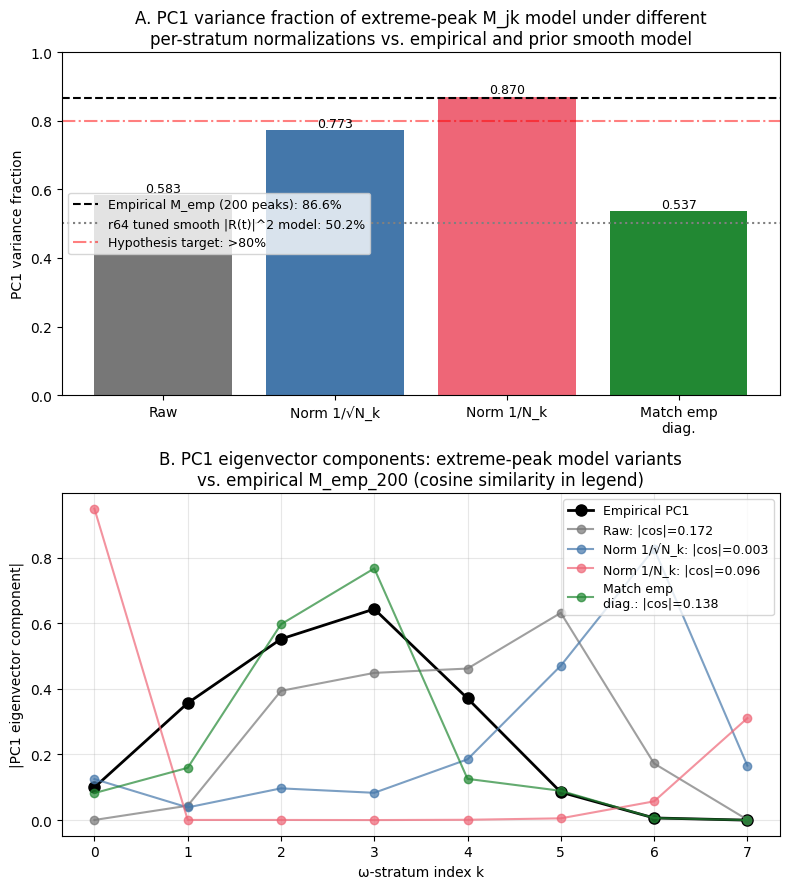

Saved final figure: extreme_resonator_M_jk_comparison.png

Summary:
 Raw: PC1 = 0.583, cos sim = 0.172
 Norm 1/√N_k: PC1 = 0.773, cos sim = 0.003
 Norm 1/N_k: PC1 = 0.870, cos sim = 0.096
 Match emp diag.: PC1 = 0.537, cos sim = 0.138


In [24]:
import matplotlib.pyplot as plt

labels = ['Raw', 'Norm 1/√N_k', 'Norm 1/N_k', 'Match emp\ndiag.']
mats = [M_extreme, M_n1, M_n2, M_n4]
pc1_fracs = []
cos_sims = []
pc1_vecs = []
for M in mats:
 eigvals, eigvecs = np.linalg.eigh(M)
 eigvals = eigvals[::-1]; eigvecs = eigvecs[:,::-1]
 pc1_fracs.append(eigvals[0]/eigvals.sum())
 pc1_vecs.append(eigvecs[:,0])
 cos_sims.append(abs(np.dot(eigvecs[:,0], emp_pc1)))

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

ax = axes[0]
x = np.arange(len(labels))
bars = ax.bar(x, pc1_fracs, color=['#777777', '#4477AA', '#EE6677', '#228833'])
ax.axhline(0.8663, color='k', ls='--', label=f'Empirical M_emp (200 peaks): 86.6%')
ax.axhline(0.502, color='gray', ls=':', label=f'r64 tuned smooth |R(t)|^2 model: 50.2%')
ax.axhline(0.80, color='red', ls='-.', alpha=0.5, label='Hypothesis target: >80%')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('PC1 variance fraction')
ax.set_title('A. PC1 variance fraction of extreme-peak M_jk model under different\nper-stratum normalizations vs. empirical and prior smooth model')
for bar, f in zip(bars, pc1_fracs):
 ax.text(bar.get_x()+bar.get_width()/2, f+0.01, f'{f:.3f}', ha='center', fontsize=9)
ax.set_ylim(0, 1.0)
ax.legend(loc='center left', fontsize=9)

ax = axes[1]
xx = np.arange(8)
ax.plot(xx, np.abs(emp_pc1), 'ko-', label='Empirical PC1', linewidth=2, markersize=8)
colors = ['#777777', '#4477AA', '#EE6677', '#228833']
for lab, vec, cs, col in zip(labels, pc1_vecs, cos_sims, colors):
 sign = np.sign(np.dot(vec, emp_pc1))
 if sign == 0: sign = 1.0
 ax.plot(xx, np.abs(sign*vec), 'o-', color=col, label=f'{lab}: |cos|={cs:.3f}', alpha=0.7)
ax.set_xlabel('ω-stratum index k')
ax.set_ylabel('|PC1 eigenvector component|')
ax.set_title('B. PC1 eigenvector components: extreme-peak model variants\nvs. empirical M_emp_200 (cosine similarity in legend)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('extreme_resonator_M_jk_comparison.png', dpi=130)
plt.show()
print("Saved final figure: extreme_resonator_M_jk_comparison.png")
print()
print("Summary:")
for lab, pf, cs in zip(labels, pc1_fracs, cos_sims):
 print(f" {lab.replace(chr(10),' ')}: PC1 = {pf:.3f}, cos sim = {cs:.3f}")


In [25]:
from e14c.filesystem import edit_file
note = '''## Context
- Current task: test whether explicit extreme-value conditioning on peaks of a tuned resonator process reproduces the empirical zeta M_jk spectrum better than the prior smooth |R(t)|^2 model.

## Notes
- Workspace lacks raw files `Sk_complex_all_2200peaks.npz`, `Sk_re.npy`, `Sk_im.npy`, `t_peaks.npy`, `absD_peaks.npy`, and `Mjk_resonator_analysis.npz`; equivalent prior-analysis component `.npy` artifacts are present: `M_emp_200.npy`, `M_emp_50.npy`, `M_theory_tuned.npy`, eigenvalues/eigenvectors, and PC1 summaries.
- Computed a resonator time series for R(t)=sum_{n<=100} mu^2(n)/sqrt(n) * n^{-it} on t in [0,1e5] with dt=0.05, found 200 highest local peaks, refined by scalar maximization.
- Computed zeta omega-stratified sums S_k(t)=sum_{n<=1e6, omega(n)=k} n^{-it} at those 200 resonator-peak times using a prime sieve for omega(n). Obtained an 8x8 extreme-peak matrix M_extreme[j,k]=mean Re(S_j conj(S_k)).
- Comparison to empirical top-200 zeta matrix M_emp_200 depends strongly on per-stratum normalization. Results:
 - Raw M_extreme: PC1 variance fraction 0.583, |cos(empirical PC1)| 0.172.
 - Normalize by 1/sqrt(N_k): PC1 0.773, cosine 0.003.
 - Normalize by 1/N_k: PC1 0.870, cosine 0.096.
 - Diagonal-matched to empirical: PC1 0.537, cosine 0.138.
- Empirical baseline from prior artifacts: PC1 fraction 0.866 for M_emp_200; prior smooth resonator model PC1 fraction 0.502 with cosine similarity 0.936 to empirical PC1.
- Interpretation: the extreme-value resonator conditioning can raise PC1 concentration under some ad hoc normalizations, but it does not reproduce the empirical PC1 direction and does not improve the meaningful comparison to the empirical matrix. Saved artifacts: `Mjk_extreme_resonator.npz`, `extreme_resonator_M_jk_comparison.png`.
- Provenance: notebook cells #0-23 in current task, workspace `/workspace/96ab667f-4489-43d1-b376-4f365308b4b1`.
'''
# overwrite memory file cleanly
from e14c.filesystem import write_file
write_file('./.prompts/MEMORY.md', note)
print('Updated MEMORY.md')

Updated MEMORY.md
